In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("mushroom.csv", index_col=0)
df.head()

,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,stalk_shape,...,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
1167,sunken,scaly,white,no,anise,descending,distant,broad,pink,tapering,...,partial,brown,two,sheathing,chocolate,clustered,waste,poisonous,14.276173,5.054983
1037,sunken,fibrous,red,no,anise,notched,crowded,narrow,chocolate,enlarging,...,universal,brown,two,sheathing,brown,numerous,waste,edible,3.952715,19.068319
309,flat,grooves,purple,yes,foul,descending,crowded,broad,purple,tapering,...,universal,yellow,two,sheathing,purple,abundant,waste,poisonous,9.054265,7.205884
282,bell,scaly,pink,yes,fishy,notched,close,broad,orange,enlarging,...,partial,yellow,two,cobwebby,green,clustered,grasses,poisonous,5.226499,20.932692
820,flat,smooth,yellow,yes,musty,free,crowded,narrow,orange,enlarging,...,universal,white,none,none,yellow,clustered,urban,poisonous,14.037532,12.545245


In [ ]:
#Unnamed column made as index

In [3]:
print(df.shape)

(2000, 25)


In [4]:
df.info()

<class 'pandas.DataFrame'>
Index: 2000 entries, 1167 to 1073
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cap_shape                 2000 non-null   str    
 1   cap_surface               2000 non-null   str    
 2   cap_color                 2000 non-null   str    
 3   bruises                   2000 non-null   str    
 4   odor                      2000 non-null   str    
 5   gill_attachment           2000 non-null   str    
 6   gill_spacing              2000 non-null   str    
 7   gill_size                 2000 non-null   str    
 8   gill_color                2000 non-null   str    
 9   stalk_shape               2000 non-null   str    
 10  stalk_root                2000 non-null   str    
 11  stalk_surface_above_ring  2000 non-null   str    
 12  stalk_surface_below_ring  2000 non-null   str    
 13  stalk_color_above_ring    2000 non-null   str    
 14  stalk_color_below_rin

# Exploratory Data Analysis (EDA)

In [ ]:
# Check Null values

In [5]:
print(df.isnull().sum())

cap_shape                   0
cap_surface                 0
cap_color                   0
bruises                     0
odor                        0
gill_attachment             0
gill_spacing                0
gill_size                   0
gill_color                  0
stalk_shape                 0
stalk_root                  0
stalk_surface_above_ring    0
stalk_surface_below_ring    0
stalk_color_above_ring      0
stalk_color_below_ring      0
veil_type                   0
veil_color                  0
ring_number                 0
ring_type                   0
spore_print_color           0
population                  0
habitat                     0
class                       0
stalk_height                0
cap_diameter                0
dtype: int64


In [ ]:
# Dataset has no null values

# Class Distribution

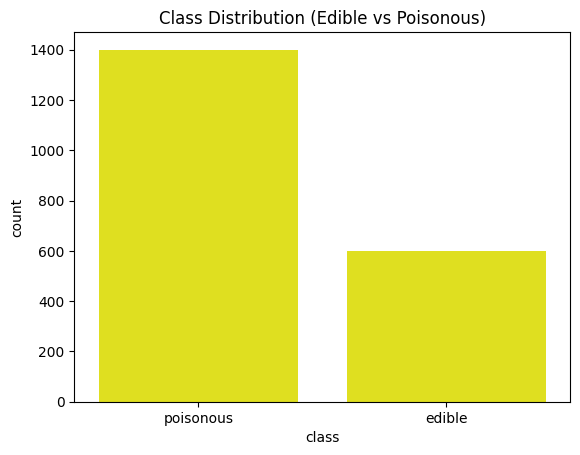

In [6]:
sns.countplot(x='class', data=df, color="Yellow")
plt.title("Class Distribution (Edible vs Poisonous)")
plt.show()

In [ ]:
# data is not balanced.

# Feature Distribution

In [7]:
print(df.columns)

Index(['cap_shape', 'cap_surface', 'cap_color', 'bruises', 'odor',
       'gill_attachment', 'gill_spacing', 'gill_size', 'gill_color',
       'stalk_shape', 'stalk_root', 'stalk_surface_above_ring',
       'stalk_surface_below_ring', 'stalk_color_above_ring',
       'stalk_color_below_ring', 'veil_type', 'veil_color', 'ring_number',
       'ring_type', 'spore_print_color', 'population', 'habitat', 'class',
       'stalk_height', 'cap_diameter'],
      dtype='str')


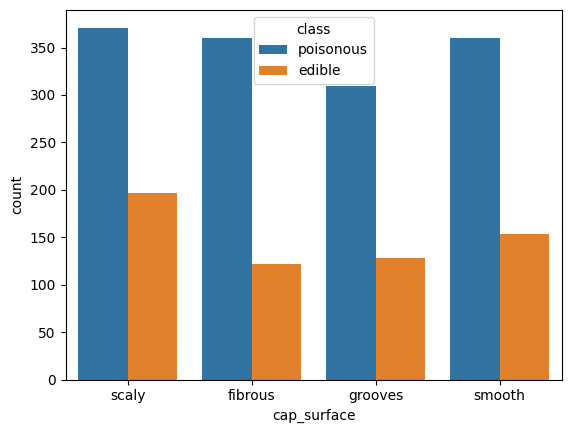

In [8]:
sns.countplot(x='cap_surface', hue='class', data=df)
plt.show()

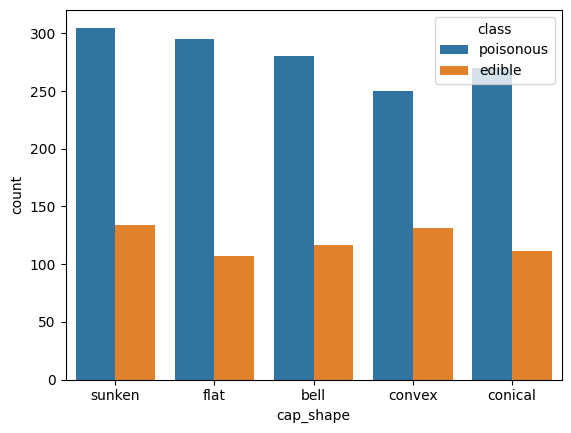

In [9]:
sns.countplot(x='cap_shape', hue='class', data=df)
plt.show()

# Correlation

In [10]:
from sklearn.preprocessing import LabelEncoder

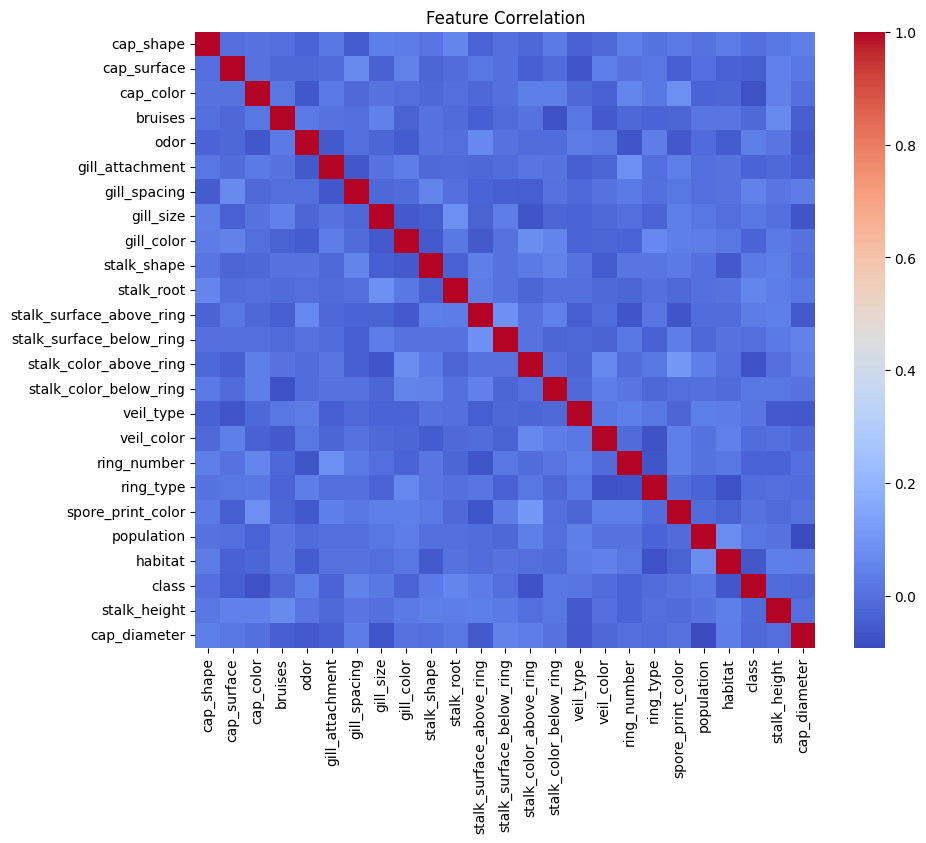

In [11]:
le = LabelEncoder()
df_encoded = df.apply(le.fit_transform)

plt.figure(figsize=(10,8))
sns.heatmap(df_encoded.corr(), cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

# Data Preprocessing(data_split)

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X = df_encoded.drop('class', axis=1)
y = df_encoded['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [14]:
from sklearn.preprocessing import StandardScaler

In [15]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) 
X_test = scaler.transform(X_test)  

# Data Visualization

In [ ]:
# Pair Plot

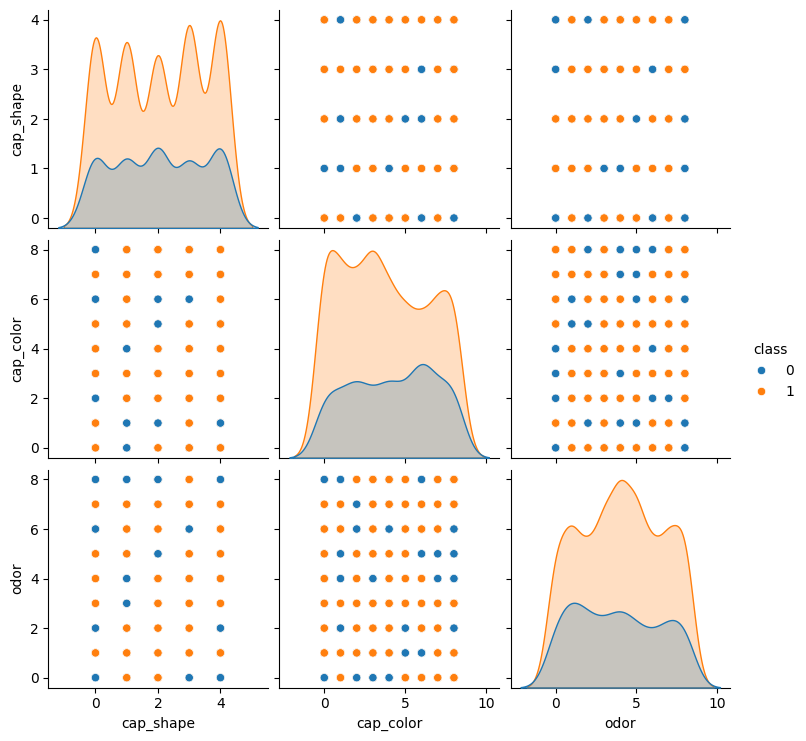

In [16]:
sns.pairplot(df_encoded[['class','cap_shape','cap_color','odor']], hue='class')
plt.show()

# Scatter Plot

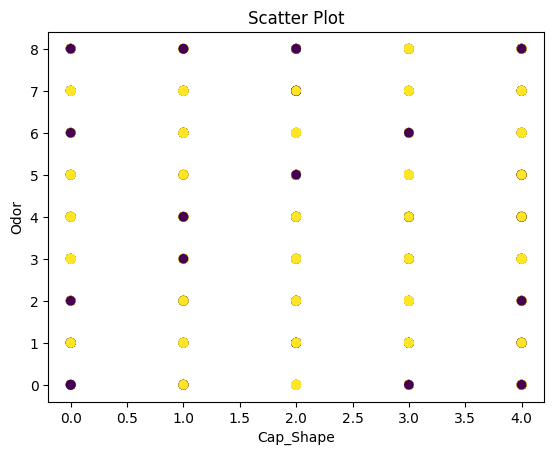

In [17]:
plt.scatter(df_encoded['cap_shape'], df_encoded['odor'], c=df_encoded['class'])
plt.xlabel("Cap_Shape")
plt.ylabel("Odor")
plt.title("Scatter Plot")
plt.show()

# SVM Implementation

In [23]:
from sklearn.svm import SVC

In [24]:
model = SVC(kernel='rbf', C=1, gamma='scale')
model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


# Predictions

In [25]:
y_pred = model.predict(X_test)

# Evaluation

In [26]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Accuracy: 0.78

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.37      0.53       133
           1       0.76      0.99      0.86       267

    accuracy                           0.78       400
   macro avg       0.84      0.68      0.69       400
weighted avg       0.81      0.78      0.75       400



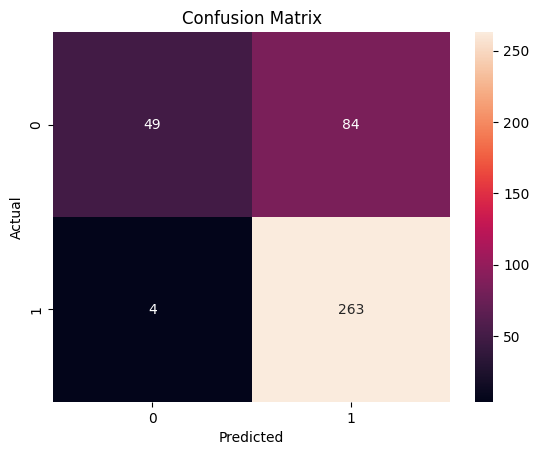

In [27]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Visualization of Results

In [28]:
from sklearn.decomposition import PCA

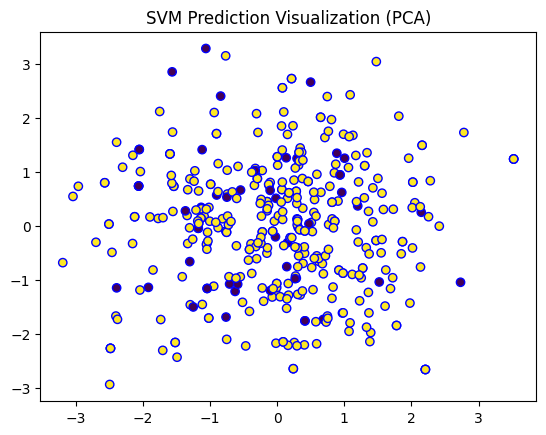

In [32]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_test)
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_pred, edgecolor = "b")
plt.title("SVM Prediction Visualization (PCA)")
plt.show()

# Hyperparameter Tuning

In [33]:
from sklearn.model_selection import GridSearchCV

In [34]:
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly']}
grid = GridSearchCV(SVC(), param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 10, 'kernel': 'poly'}


# Comparison of Kernels

In [35]:
kernels = ['linear', 'rbf', 'poly']

for k in kernels:
    model = SVC(kernel=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    print(f"\nKernel: {k}")
    print("Accuracy:", accuracy_score(y_test, pred))


Kernel: linear
Accuracy: 0.6675

Kernel: rbf
Accuracy: 0.78

Kernel: poly
Accuracy: 0.8225


# Interpretation

In [ ]:
# Strengths of SVM are it Works well with high-dimensional data, Very effective for classification problems and Mushroom dataset is giving goodaccuracy
its weaknesses are that it required parametertuning and slow

In [ ]:
# Real-World Use are Disease detection, Spam email classification
 Fraud detection and Image classification